In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

importing the dataframe and checking out

In [2]:
df = pd.read_csv('KaggleV2-May-2016.csv')
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [4]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [5]:
print(df['PatientId'].nunique())

print(df['AppointmentID'].nunique())

62299
110527


-> patients are repeated

In [6]:
# retrieve days in proper months,days and hours to monitor data
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])

df['ScheduledMonth'] = df['ScheduledDay'].dt.month
df['ScheduledDayOfMonth'] = df['ScheduledDay'].dt.day
df['ScheduledHour'] = df['ScheduledDay'].dt.hour
df['ScheduledMinute'] = df['ScheduledDay'].dt.minute

# retrieve days in proper months, days and hours to monitor data for appointment days
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['AppointmentMonth'] = df['AppointmentDay'].dt.month
df['AppointmentDayOfMonth'] = df['AppointmentDay'].dt.day
df['AppointmentHour'] = df['AppointmentDay'].dt.hour
df['AppointmentMinute'] = df['AppointmentDay'].dt.minute

#Update - add weeks of the day and one-hot encode it
# df['ScheduledWeekday'] = df['ScheduledDay'].dt.dayofweek #drop scheduled weekday
df['AppointmentWeekday'] = df['AppointmentDay'].dt.dayofweek

# Calculate precise time gap as float 
scheduled_full = df['ScheduledDay'] + pd.to_timedelta(df['ScheduledHour'], unit='h') + pd.to_timedelta(df['ScheduledMinute'], unit='m')
appointment_full = df['AppointmentDay'] + pd.to_timedelta(df['AppointmentHour'], unit='h') + pd.to_timedelta(df['AppointmentMinute'], unit='m')

# Compute precise time gap in float days
df['GapFloatDays'] = (appointment_full - scheduled_full).dt.total_seconds() / (24 * 3600)

df = pd.get_dummies(df, columns=['AppointmentWeekday', 'AppointmentMonth', 'AppointmentDayOfMonth','ScheduledMonth', 'ScheduledDayOfMonth' \
                                 ,'ScheduledHour', 'ScheduledMinute', 'Age', 'Gender'])
#Handicap is labeled 0 to 4

# Count number of negative values in GapFloatDays
negative_gap_count = (df['GapFloatDays'] < 0).sum()
negative_but_more = (df['GapFloatDays'] < -1).sum()
print(f"Number of negative gap values: {negative_gap_count}")
print(f"Negative more than 1 day: {negative_but_more}")


print((df['AppointmentHour'] == 0).sum())
print((df['AppointmentMinute'] == 0).sum())

Number of negative gap values: 40972
Negative more than 1 day: 12161
110527
110527


In [7]:
df['GapFloatDays'] = df['GapFloatDays'].clip(lower=0)
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df['GapFloatDays_scaled'] = scaler.fit_transform(df[['GapFloatDays']])

#works better without scaling, try squaring
df

,PatientId,AppointmentID,ScheduledDay,AppointmentDay,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,AppointmentHour,AppointmentMinute,GapFloatDays,AppointmentWeekday_0,AppointmentWeekday_1,AppointmentWeekday_2,AppointmentWeekday_3,AppointmentWeekday_4,AppointmentWeekday_5,AppointmentMonth_4,AppointmentMonth_5,AppointmentMonth_6,AppointmentDayOfMonth_1,AppointmentDayOfMonth_2,AppointmentDayOfMonth_3,AppointmentDayOfMonth_4,AppointmentDayOfMonth_5,AppointmentDayOfMonth_6,AppointmentDayOfMonth_7,AppointmentDayOfMonth_8,AppointmentDayOfMonth_9,AppointmentDayOfMonth_10,AppointmentDayOfMonth_11,AppointmentDayOfMonth_12,AppointmentDayOfMonth_13,AppointmentDayOfMonth_14,AppointmentDayOfMonth_16,AppointmentDayOfMonth_17,AppointmentDayOfMonth_18,AppointmentDayOfMonth_19,AppointmentDayOfMonth_20,AppointmentDayOfMonth_24,AppointmentDayOfMonth_25,AppointmentDayOfMonth_29,AppointmentDayOfMonth_30,AppointmentDayOfMonth_31,ScheduledMonth_1,ScheduledMonth_2,ScheduledMonth_3,ScheduledMonth_4,ScheduledMonth_5,ScheduledMonth_6,ScheduledMonth_11,ScheduledMonth_12,ScheduledDayOfMonth_1,ScheduledDayOfMonth_2,ScheduledDayOfMonth_3,ScheduledDayOfMonth_4,ScheduledDayOfMonth_5,ScheduledDayOfMonth_6,ScheduledDayOfMonth_7,ScheduledDayOfMonth_8,ScheduledDayOfMonth_9,ScheduledDayOfMonth_10,ScheduledDayOfMonth_11,ScheduledDayOfMonth_12,ScheduledDayOfMonth_13,ScheduledDayOfMonth_14,ScheduledDayOfMonth_15,ScheduledDayOfMonth_16,ScheduledDayOfMonth_17,ScheduledDayOfMonth_18,ScheduledDayOfMonth_19,ScheduledDayOfMonth_20,ScheduledDayOfMonth_21,ScheduledDayOfMonth_22,ScheduledDayOfMonth_23,ScheduledDayOfMonth_24,ScheduledDayOfMonth_25,ScheduledDayOfMonth_26,ScheduledDayOfMonth_27,ScheduledDayOfMonth_28,ScheduledDayOfMonth_29,ScheduledDayOfMonth_30,ScheduledDayOfMonth_31,ScheduledHour_6,ScheduledHour_7,ScheduledHour_8,ScheduledHour_9,ScheduledHour_10,ScheduledHour_11,ScheduledHour_12,ScheduledHour_13,ScheduledHour_14,ScheduledHour_15,ScheduledHour_16,ScheduledHour_17,ScheduledHour_18,ScheduledHour_19,ScheduledHour_20,ScheduledHour_21,ScheduledMinute_0,ScheduledMinute_1,ScheduledMinute_2,ScheduledMinute_3,ScheduledMinute_4,ScheduledMinute_5,ScheduledMinute_6,ScheduledMinute_7,ScheduledMinute_8,ScheduledMinute_9,ScheduledMinute_10,ScheduledMinute_11,ScheduledMinute_12,ScheduledMinute_13,ScheduledMinute_14,ScheduledMinute_15,ScheduledMinute_16,ScheduledMinute_17,ScheduledMinute_18,ScheduledMinute_19,ScheduledMinute_20,ScheduledMinute_21,ScheduledMinute_22,ScheduledMinute_23,ScheduledMinute_24,ScheduledMinute_25,ScheduledMinute_26,ScheduledMinute_27,ScheduledMinute_28,ScheduledMinute_29,ScheduledMinute_30,ScheduledMinute_31,ScheduledMinute_32,ScheduledMinute_33,ScheduledMinute_34,ScheduledMinute_35,ScheduledMinute_36,ScheduledMinute_37,ScheduledMinute_38,ScheduledMinute_39,ScheduledMinute_40,ScheduledMinute_41,ScheduledMinute_42,ScheduledMinute_43,ScheduledMinute_44,ScheduledMinute_45,ScheduledMinute_46,ScheduledMinute_47,ScheduledMinute_48,ScheduledMinute_49,ScheduledMinute_50,ScheduledMinute_51,ScheduledMinute_52,ScheduledMinute_53,ScheduledMinute_54,ScheduledMinute_55,ScheduledMinute_56,ScheduledMinute_57,ScheduledMinute_58,ScheduledMinute_59,Age_-1,Age_0,Age_1,Age_2,Age_3,Age_4,Age_5,Age_6,Age_7,Age_8,Age_9,Age_10,Age_11,Age_12,Age_13,Age_14,Age_15,Age_16,Age_17,Age_18,Age_19,Age_20,Age_21,Age_22,Age_23,Age_24,Age_25,Age_26,Age_27,Age_28,Age_29,Age_30,Age_31,Age_32,Age_33,Age_34,Age_35,Age_36,Age_37,Age_38,Age_39,Age_40,Age_41,Age_42,Age_43,Age_44,Age_45,Age_46,Age_47,Age_48,Age_49,Age_50,Age_51,Age_52,Age_53,Age_54,Age_55,Age_56,Age_57,Age_58,Age_59,Age_60,Age_61,Age_62,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70,Age_71,Age_72,Age_73,Age_74,Age_75,Age_76,Age_77,Age_78,Age_79,Age_80,Age_81,Age_82,Age_83,Age_84,Age_85,Age_86,Age_87,Age_88,Age_89,Age_90,Age_91,Age_92,Age_93,Age_94,Age_95,Age_96,Age_97,Age_98,Age_99,Age_100,Age_102,Age_115,Gender_F,Gender_M
0,2.987250e+13,5642903,2016-04-29 18:38:08+00:00,2016-04-29

In [8]:
# Step 1: Count total appointments per patient
total_appointments = df.groupby('PatientId').size()

# Step 2: Count attended appointments (where No-show == 'No')
attended_appointments = df[df['No-show'] == 'No'].groupby('PatientId').size()

# Step 3: Compute show-up rate
show_rate = (attended_appointments / total_appointments).fillna(0)

# Step 4: Map back to the main dataframe
df['Patient_Show_Rate'] = df['PatientId'].map(show_rate)

In [9]:
# drop patientIds and AppointmentIDs columns, ScheduledDay, AppointmentDay, AppointmentHour and AppointmentMinute since they are just zero
cols_to_drop = ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay', 'AppointmentHour', 'AppointmentMinute']
df = df.drop(cols_to_drop, axis=1)
df

,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,GapFloatDays,AppointmentWeekday_0,AppointmentWeekday_1,AppointmentWeekday_2,AppointmentWeekday_3,AppointmentWeekday_4,AppointmentWeekday_5,AppointmentMonth_4,AppointmentMonth_5,AppointmentMonth_6,AppointmentDayOfMonth_1,AppointmentDayOfMonth_2,AppointmentDayOfMonth_3,AppointmentDayOfMonth_4,AppointmentDayOfMonth_5,AppointmentDayOfMonth_6,AppointmentDayOfMonth_7,AppointmentDayOfMonth_8,AppointmentDayOfMonth_9,AppointmentDayOfMonth_10,AppointmentDayOfMonth_11,AppointmentDayOfMonth_12,AppointmentDayOfMonth_13,AppointmentDayOfMonth_14,AppointmentDayOfMonth_16,AppointmentDayOfMonth_17,AppointmentDayOfMonth_18,AppointmentDayOfMonth_19,AppointmentDayOfMonth_20,AppointmentDayOfMonth_24,AppointmentDayOfMonth_25,AppointmentDayOfMonth_29,AppointmentDayOfMonth_30,AppointmentDayOfMonth_31,ScheduledMonth_1,ScheduledMonth_2,ScheduledMonth_3,ScheduledMonth_4,ScheduledMonth_5,ScheduledMonth_6,ScheduledMonth_11,ScheduledMonth_12,ScheduledDayOfMonth_1,ScheduledDayOfMonth_2,ScheduledDayOfMonth_3,ScheduledDayOfMonth_4,ScheduledDayOfMonth_5,ScheduledDayOfMonth_6,ScheduledDayOfMonth_7,ScheduledDayOfMonth_8,ScheduledDayOfMonth_9,ScheduledDayOfMonth_10,ScheduledDayOfMonth_11,ScheduledDayOfMonth_12,ScheduledDayOfMonth_13,ScheduledDayOfMonth_14,ScheduledDayOfMonth_15,ScheduledDayOfMonth_16,ScheduledDayOfMonth_17,ScheduledDayOfMonth_18,ScheduledDayOfMonth_19,ScheduledDayOfMonth_20,ScheduledDayOfMonth_21,ScheduledDayOfMonth_22,ScheduledDayOfMonth_23,ScheduledDayOfMonth_24,ScheduledDayOfMonth_25,ScheduledDayOfMonth_26,ScheduledDayOfMonth_27,ScheduledDayOfMonth_28,ScheduledDayOfMonth_29,ScheduledDayOfMonth_30,ScheduledDayOfMonth_31,ScheduledHour_6,ScheduledHour_7,ScheduledHour_8,ScheduledHour_9,ScheduledHour_10,ScheduledHour_11,ScheduledHour_12,ScheduledHour_13,ScheduledHour_14,ScheduledHour_15,ScheduledHour_16,ScheduledHour_17,ScheduledHour_18,ScheduledHour_19,ScheduledHour_20,ScheduledHour_21,ScheduledMinute_0,ScheduledMinute_1,ScheduledMinute_2,ScheduledMinute_3,ScheduledMinute_4,ScheduledMinute_5,ScheduledMinute_6,ScheduledMinute_7,ScheduledMinute_8,ScheduledMinute_9,ScheduledMinute_10,ScheduledMinute_11,ScheduledMinute_12,ScheduledMinute_13,ScheduledMinute_14,ScheduledMinute_15,ScheduledMinute_16,ScheduledMinute_17,ScheduledMinute_18,ScheduledMinute_19,ScheduledMinute_20,ScheduledMinute_21,ScheduledMinute_22,ScheduledMinute_23,ScheduledMinute_24,ScheduledMinute_25,ScheduledMinute_26,ScheduledMinute_27,ScheduledMinute_28,ScheduledMinute_29,ScheduledMinute_30,ScheduledMinute_31,ScheduledMinute_32,ScheduledMinute_33,ScheduledMinute_34,ScheduledMinute_35,ScheduledMinute_36,ScheduledMinute_37,ScheduledMinute_38,ScheduledMinute_39,ScheduledMinute_40,ScheduledMinute_41,ScheduledMinute_42,ScheduledMinute_43,ScheduledMinute_44,ScheduledMinute_45,ScheduledMinute_46,ScheduledMinute_47,ScheduledMinute_48,ScheduledMinute_49,ScheduledMinute_50,ScheduledMinute_51,ScheduledMinute_52,ScheduledMinute_53,ScheduledMinute_54,ScheduledMinute_55,ScheduledMinute_56,ScheduledMinute_57,ScheduledMinute_58,ScheduledMinute_59,Age_-1,Age_0,Age_1,Age_2,Age_3,Age_4,Age_5,Age_6,Age_7,Age_8,Age_9,Age_10,Age_11,Age_12,Age_13,Age_14,Age_15,Age_16,Age_17,Age_18,Age_19,Age_20,Age_21,Age_22,Age_23,Age_24,Age_25,Age_26,Age_27,Age_28,Age_29,Age_30,Age_31,Age_32,Age_33,Age_34,Age_35,Age_36,Age_37,Age_38,Age_39,Age_40,Age_41,Age_42,Age_43,Age_44,Age_45,Age_46,Age_47,Age_48,Age_49,Age_50,Age_51,Age_52,Age_53,Age_54,Age_55,Age_56,Age_57,Age_58,Age_59,Age_60,Age_61,Age_62,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70,Age_71,Age_72,Age_73,Age_74,Age_75,Age_76,Age_77,Age_78,Age_79,Age_80,Age_81,Age_82,Age_83,Age_84,Age_85,Age_86,Age_87,Age_88,Age_89,Age_90,Age_91,Age_92,Age_93,Age_94,Age_95,Age_96,Age_97,Age_98,Age_99,Age_100,Age_102,Age_115,Gender_F,Gender_M,Patient_Show_Rate
0,JARDIM DA PENHA,0,1,0,0,0,0,No,0.000000,False,False,False,False,True,False,True,False,False,False,False,False,False,False,Fal

In [10]:
# one-hot encode neighbourhood
df = pd.get_dummies(df, columns=['Neighbourhood'])

#binary encode no-show
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})

In [11]:
df

,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,GapFloatDays,AppointmentWeekday_0,AppointmentWeekday_1,AppointmentWeekday_2,AppointmentWeekday_3,AppointmentWeekday_4,AppointmentWeekday_5,AppointmentMonth_4,AppointmentMonth_5,AppointmentMonth_6,AppointmentDayOfMonth_1,AppointmentDayOfMonth_2,AppointmentDayOfMonth_3,AppointmentDayOfMonth_4,AppointmentDayOfMonth_5,AppointmentDayOfMonth_6,AppointmentDayOfMonth_7,AppointmentDayOfMonth_8,AppointmentDayOfMonth_9,AppointmentDayOfMonth_10,AppointmentDayOfMonth_11,AppointmentDayOfMonth_12,AppointmentDayOfMonth_13,AppointmentDayOfMonth_14,AppointmentDayOfMonth_16,AppointmentDayOfMonth_17,AppointmentDayOfMonth_18,AppointmentDayOfMonth_19,AppointmentDayOfMonth_20,AppointmentDayOfMonth_24,AppointmentDayOfMonth_25,AppointmentDayOfMonth_29,AppointmentDayOfMonth_30,AppointmentDayOfMonth_31,ScheduledMonth_1,ScheduledMonth_2,ScheduledMonth_3,ScheduledMonth_4,ScheduledMonth_5,ScheduledMonth_6,ScheduledMonth_11,ScheduledMonth_12,ScheduledDayOfMonth_1,ScheduledDayOfMonth_2,ScheduledDayOfMonth_3,ScheduledDayOfMonth_4,ScheduledDayOfMonth_5,ScheduledDayOfMonth_6,ScheduledDayOfMonth_7,ScheduledDayOfMonth_8,ScheduledDayOfMonth_9,ScheduledDayOfMonth_10,ScheduledDayOfMonth_11,ScheduledDayOfMonth_12,ScheduledDayOfMonth_13,ScheduledDayOfMonth_14,ScheduledDayOfMonth_15,ScheduledDayOfMonth_16,ScheduledDayOfMonth_17,ScheduledDayOfMonth_18,ScheduledDayOfMonth_19,ScheduledDayOfMonth_20,ScheduledDayOfMonth_21,ScheduledDayOfMonth_22,ScheduledDayOfMonth_23,ScheduledDayOfMonth_24,ScheduledDayOfMonth_25,ScheduledDayOfMonth_26,ScheduledDayOfMonth_27,ScheduledDayOfMonth_28,ScheduledDayOfMonth_29,ScheduledDayOfMonth_30,ScheduledDayOfMonth_31,ScheduledHour_6,ScheduledHour_7,ScheduledHour_8,ScheduledHour_9,ScheduledHour_10,ScheduledHour_11,ScheduledHour_12,ScheduledHour_13,ScheduledHour_14,ScheduledHour_15,ScheduledHour_16,ScheduledHour_17,ScheduledHour_18,ScheduledHour_19,ScheduledHour_20,ScheduledHour_21,ScheduledMinute_0,ScheduledMinute_1,ScheduledMinute_2,ScheduledMinute_3,ScheduledMinute_4,ScheduledMinute_5,ScheduledMinute_6,ScheduledMinute_7,ScheduledMinute_8,ScheduledMinute_9,ScheduledMinute_10,ScheduledMinute_11,ScheduledMinute_12,ScheduledMinute_13,ScheduledMinute_14,ScheduledMinute_15,ScheduledMinute_16,ScheduledMinute_17,ScheduledMinute_18,ScheduledMinute_19,ScheduledMinute_20,ScheduledMinute_21,ScheduledMinute_22,ScheduledMinute_23,ScheduledMinute_24,ScheduledMinute_25,ScheduledMinute_26,ScheduledMinute_27,ScheduledMinute_28,ScheduledMinute_29,ScheduledMinute_30,ScheduledMinute_31,ScheduledMinute_32,ScheduledMinute_33,ScheduledMinute_34,ScheduledMinute_35,ScheduledMinute_36,ScheduledMinute_37,ScheduledMinute_38,ScheduledMinute_39,ScheduledMinute_40,ScheduledMinute_41,ScheduledMinute_42,ScheduledMinute_43,ScheduledMinute_44,ScheduledMinute_45,ScheduledMinute_46,ScheduledMinute_47,ScheduledMinute_48,ScheduledMinute_49,ScheduledMinute_50,ScheduledMinute_51,ScheduledMinute_52,ScheduledMinute_53,ScheduledMinute_54,ScheduledMinute_55,ScheduledMinute_56,ScheduledMinute_57,ScheduledMinute_58,ScheduledMinute_59,Age_-1,Age_0,Age_1,Age_2,Age_3,Age_4,Age_5,Age_6,Age_7,Age_8,Age_9,Age_10,Age_11,Age_12,Age_13,Age_14,Age_15,Age_16,Age_17,Age_18,Age_19,Age_20,Age_21,Age_22,Age_23,Age_24,Age_25,Age_26,Age_27,Age_28,Age_29,Age_30,Age_31,Age_32,Age_33,Age_34,Age_35,Age_36,Age_37,Age_38,Age_39,Age_40,Age_41,Age_42,Age_43,Age_44,Age_45,Age_46,Age_47,Age_48,Age_49,Age_50,Age_51,Age_52,Age_53,Age_54,Age_55,Age_56,Age_57,Age_58,Age_59,Age_60,Age_61,Age_62,Age_63,Age_64,Age_65,Age_66,Age_67,Age_68,Age_69,Age_70,Age_71,Age_72,Age_73,Age_74,Age_75,Age_76,Age_77,Age_78,Age_79,Age_80,Age_81,Age_82,Age_83,Age_84,Age_85,Age_86,Age_87,Age_88,Age_89,Age_90,Age_91,Age_92,Age_93,Age_94,Age_95,Age_96,Age_97,Age_98,Age_99,Age_100,Age_102,Age_115,Gender_F,Gender_M,Patient_Show_Rate,Neighbourhood_AEROPORTO,Neighbourhood_ANDORINHAS,Neighbourhood_ANTÔNIO HONÓRIO,Neighbourhood_ARIOVALDO FAVALESSA,Neighbourhood_BARRO VERMELHO

Now let's start coding the neural network

In [12]:
#Dense layer
class Layer_Dense:
    #Layer_initialization
    def __init__(self, n_inputs, n_neurons, weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        #Set regularization strength
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2

    #Forward pass
    def forward(self, inputs):
        self.inputs = inputs
        # Calculation of output values 
        self.output = np.dot(inputs, self.weights) + self.biases

    #Backward pass
    def backward(self, dvalues):
        #Gradient on parameters
        self.dweights = np.dot(self.inputs.T, dvalues) # X.T * dl_dz
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)

        # Update gradients after regularization
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights

        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        #Gradient on values
        self.dinputs = np.dot(dvalues, self.weights.T) # dl_dz * W.T

In [13]:
#ReLU activation
class Activation_ReLU:
    #Forward pass
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    #Backward pass
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        #Zero gradient where inputs were negative
        self.dinputs[self.inputs <= 0] = 0

In [14]:
#Softmax activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # print(f"Softmax inputs type: {type(inputs)}, shape: {np.shape(inputs)}")
        inputs = np.array(inputs, dtype=np.float64)
        
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        #Normalize probabilities
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities

In [15]:
class Loss:
    # Regularization loss calculation
    def regularization_loss(self, layer):
        regularization_loss = 0  # by default

        # If L2 regularization
        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights**2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases**2)  

        return regularization_loss

    # Calculate the losses with class weights
    def calculate(self, output, y, class_weights=None):
        # Calculate sample losses (shape: batch_size,)
        sample_losses = self.forward(output, y)  # e.g., cross-entropy per sample

        if class_weights is not None:
            # If y is one-hot encoded, get class index for each sample
            if len(y.shape) == 2:
                class_indices = np.argmax(y, axis=1)
            else:
                class_indices = y

            # Map weights to each sample
            weights = class_weights[class_indices]

            # Apply weights to sample losses
            weighted_losses = sample_losses * weights

            # Calculate weighted mean loss
            data_loss = np.mean(weighted_losses)
        else:
            # No weighting, normal mean loss
            data_loss = np.mean(sample_losses)

        return data_loss

In [16]:
#Using categorical cross Entropy loss
class Loss_CategoricalCrossEntropy(Loss):
    #Forward pass
    def forward(self, y_pred, y_true):
        #number of samples in a batch
        samples = len(y_pred)

        #Clip data
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)

        # Probabilities for target values - 
        # if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values for one hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis = 1
            )

        #Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

    #Backward pass
    def backward(self, dvalues, y_true):
        #number of samples in da batch
        samples = len(dvalues)

        #Number of labels in every sample
        labels = len(dvalues[0])

        #turn labels to one-hot
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]

        #calculate gradient
        self.dinputs = -y_true / dvalues
        # normalize it
        self.dinputs = self.dinputs / samples

In [17]:
class Activation_Softmax_Loss_CategoricalCrossEntropy:
    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossEntropy()

    # Forward pass with optional class weights
    def forward(self, inputs, y_true, class_weights=None):
        self.activation.forward(inputs)
        self.output = self.activation.output
        # Calculate and return weighted loss value
        return self.loss.calculate(self.output, y_true, class_weights=class_weights)

    # Backward pass with class weights applied to gradients
    def backward(self, dvalues, y_true, class_weights=None):
        samples = len(dvalues)
        
        # Convert one-hot to class indices
        if len(y_true.shape) == 2:
            y_true_indices = np.argmax(y_true, axis=1)
        else:
            y_true_indices = y_true
        
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true_indices] -= 1

        if class_weights is not None:
            # Create weights array per sample based on true class
            sample_weights = class_weights[y_true_indices]
            # Reshape for broadcasting
            sample_weights = sample_weights.reshape(-1, 1)
            # Scale gradients by weights
            self.dinputs *= sample_weights

        # Normalize gradients
        self.dinputs = self.dinputs / samples


In [18]:
class Optimizer_Adam:
    def __init__(self, learning_rate=1e-3, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999, gamma=0.95):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.gamma = gamma

    # Call before any parameter updates
    def pre_update_params(self):
        if self.decay:
            # Decay every 512 iterations (batches)
            decay_steps = 512
            decay_count = self.iterations // decay_steps  # integer division
            self.current_learning_rate = self.learning_rate * (self.gamma ** decay_count)


    def update_params(self, layer):
        # If layer doesn't have cache arrays, create them
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)
        # Force everything to float64 early to avoid dtype=object issues
        layer.weights = np.array(layer.weights, dtype=np.float64)
        layer.biases = np.array(layer.biases, dtype=np.float64)
        layer.weight_momentums = np.array(layer.weight_momentums, dtype=np.float64)
        layer.weight_cache = np.array(layer.weight_cache, dtype=np.float64)
        layer.bias_momentums = np.array(layer.bias_momentums, dtype=np.float64)
        layer.bias_cache = np.array(layer.bias_cache, dtype=np.float64)
    
        # fix dtype of gradients (likely source of dtype=object)
        layer.dweights = np.array(layer.dweights, dtype=np.float64)
        layer.dbiases = np.array(layer.dbiases, dtype=np.float64)
        # Update momentum with current gradients
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases

        # Get corrected momentum
        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1))

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2

        # Get corrected cache
        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))

        weight_cache_corrected = np.array(weight_cache_corrected, dtype=np.float64)
        bias_cache_corrected= np.array(bias_cache_corrected, dtype=np.float64)
  
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)

    # Call after parameter updates
    def post_update_params(self):
        self.iterations += 1


In [19]:
# implementing dropout layers
class Layer_Dropout:
    def __init__(self, rate):
        #we get the dropout rate, but save the success rate
        self.rate = 1 - rate

    #Forward pass
    def forward(self, inputs):
        self.inputs = inputs

        self.binary_mask = np.random.binomial(1, self.rate, size=inputs.shape) / self.rate
        self.output = inputs * self.binary_mask

    #Backward pass
    def backward(self, dvalues):
        self.dinputs = dvalues*self.binary_mask

Training samples: 88421
Batch size: 512
Batches per epoch: 173
Epoch: 0, Acc: 0.888, Loss: 0.351 (Data: 0.317, Reg: 0.034), LR: 0.030000, Val_Acc: 0.900, Val_Loss: 0.205
Epoch: 10, Acc: 0.911, Loss: 0.254 (Data: 0.223, Reg: 0.031), LR: 0.025721, Val_Acc: 0.907, Val_Loss: 0.184
Epoch: 20, Acc: 0.911, Loss: 0.246 (Data: 0.220, Reg: 0.027), LR: 0.020950, Val_Acc: 0.913, Val_Loss: 0.184
Epoch: 30, Acc: 0.911, Loss: 0.238 (Data: 0.216, Reg: 0.022), LR: 0.017962, Val_Acc: 0.912, Val_Loss: 0.183
Epoch: 40, Acc: 0.912, Loss: 0.233 (Data: 0.214, Reg: 0.019), LR: 0.015400, Val_Acc: 0.913, Val_Loss: 0.191
Epoch: 50, Acc: 0.912, Loss: 0.232 (Data: 0.213, Reg: 0.019), LR: 0.012544, Val_Acc: 0.914, Val_Loss: 0.181
Epoch: 60, Acc: 0.913, Loss: 0.227 (Data: 0.212, Reg: 0.015), LR: 0.010755, Val_Acc: 0.912, Val_Loss: 0.189
Epoch: 70, Acc: 0.913, Loss: 0.225 (Data: 0.211, Reg: 0.014), LR: 0.009221, Val_Acc: 0.912, Val_Loss: 0.182
Epoch: 80, Acc: 0.913, Loss: 0.221 (Data: 0.209, Reg: 0.012), LR: 0.007510

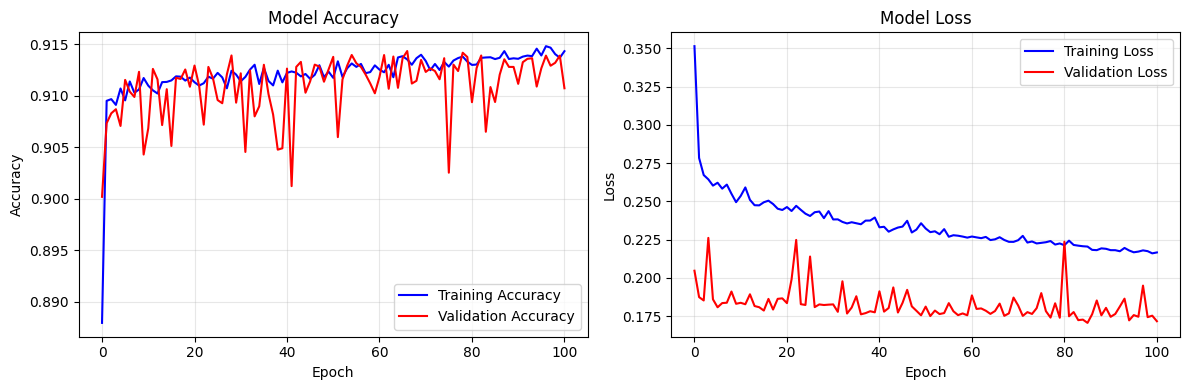

In [20]:
# Training the model with batch processing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


X = df.drop('No-show', axis=1)   # Features
y = df['No-show']             # Target

# y = pd.concat([df['No-show']] * 5, ignore_index=True)

#One-hot encode no-show
y = pd.get_dummies(df['No-show']).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to numpy arrays (was causing some bugs)
X_train = np.array(X_train, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Model architecture with 3 dense layers
dense1 = Layer_Dense(343, 64, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4)
activation1 = Activation_ReLU()
dropout1 = Layer_Dropout(0.0) #Didnt require it yet, no overfitting found, keeping it low for higher neurons test
dense2 = Layer_Dense(64, 32, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4)
activation2 = Activation_ReLU()
dropout2 = Layer_Dropout(0.0)
dense3 = Layer_Dense(32, 2)
loss_activation = Activation_Softmax_Loss_CategoricalCrossEntropy()
optimizer = Optimizer_Adam(learning_rate=0.03, decay=5e-4)  # Reduced learning rate

# Batch training parameters, for faster learning
batch_size = 512
epochs = 100
n_samples = X_train.shape[0]
n_batches = (n_samples + batch_size - 1) // batch_size  

print(f"Training samples: {n_samples}")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {n_batches}")

# Initialize history tracking
history = {
    'train_acc': [],
    'train_loss': [],
    'val_acc': [],
    'val_loss': []
}

# Validation function (moved up to use during training)
def validate_model(X_val, y_val, batch_size=batch_size):
    n_val_samples = X_val.shape[0]
    n_val_batches = (n_val_samples + batch_size - 1) // batch_size
    
    total_loss = 0
    total_accuracy = 0
    
    for batch_idx in range(n_val_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_val_samples)
        
        X_batch = X_val[start_idx:end_idx]
        y_batch = y_val[start_idx:end_idx]
        
        # Forward pass (no dropout during validation)
        dense1.forward(X_batch)
        activation1.forward(dense1.output)
        # Skip dropout during validation
        dense2.forward(activation1.output)
        activation2.forward(dense2.output)
        # Skip dropout during validation
        dense3.forward(activation2.output)
        loss = loss_activation.forward(dense3.output, y_batch)

        probs_no_show = loss_activation.output[:, 1] #gonna try this
        
        predictions = (probs_no_show > 0.65).astype(int)

        # Calculate accuracy
        # predictions = np.argmax(loss_activation.output, axis=1)
        if len(y_batch.shape) == 2:
            y_batch_labels = np.argmax(y_batch, axis=1)
        else:
            y_batch_labels = y_batch
        batch_accuracy = np.mean(predictions == y_batch_labels)
        
        total_loss += loss
        total_accuracy += batch_accuracy
    
    avg_loss = total_loss / n_val_batches
    avg_accuracy = total_accuracy / n_val_batches
    
    return avg_loss, avg_accuracy

# Training loop with batches
for epoch in range(epochs+1):
    # Shuffle data at the beginning of each epoch
    indices = np.random.permutation(n_samples)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_loss = 0
    epoch_data_loss = 0
    epoch_reg_loss = 0
    epoch_accuracy = 0
    
    # Process each batch
    for batch_idx in range(n_batches):
        # Calculate batch boundaries
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        
        # Get current batch
        X_batch = X_train_shuffled[start_idx:end_idx]
        y_batch = y_train_shuffled[start_idx:end_idx]
        
        # Forward pass
        dense1.forward(X_batch)
        activation1.forward(dense1.output)
        dropout1.forward(activation1.output)
        dense2.forward(dropout1.output)
        activation2.forward(dense2.output)
        dropout2.forward(activation2.output)
        dense3.forward(dropout2.output)
        class_weights = np.array([1.0, 1.5])  # Assuming 1 = show, 0 = no-show
        data_loss = loss_activation.forward(dense3.output, y_batch, class_weights=class_weights)
        
        # Calculate regularization penalty
        regularization_loss = (loss_activation.loss.regularization_loss(dense1) + 
                             loss_activation.loss.regularization_loss(dense2) +
                             loss_activation.loss.regularization_loss(dense3))
        
        # Calculate overall loss
        loss = data_loss + regularization_loss

        probs_no_show = loss_activation.output[:, 1] #lemme try this
        
        # Apply threshold
        predictions = (probs_no_show > 0.65).astype(int)

        # Calculate accuracy for this batch
        # predictions = np.argmax(loss_activation.output, axis=1)
        if len(y_batch.shape) == 2:
            y_batch_labels = np.argmax(y_batch, axis=1)
        else:
            y_batch_labels = y_batch
        batch_accuracy = np.mean(predictions == y_batch_labels)
        
        # Accumulate metrics
        epoch_loss += loss
        epoch_data_loss += data_loss
        epoch_reg_loss += regularization_loss
        epoch_accuracy += batch_accuracy
        
        # Backward pass
        loss_activation.backward(loss_activation.output, y_batch, class_weights=class_weights)
        dense3.backward(loss_activation.dinputs)
        dropout2.backward(dense3.dinputs)
        activation2.backward(dropout2.dinputs)
        dense2.backward(activation2.dinputs)
        dropout1.backward(dense2.dinputs)
        activation1.backward(dropout1.dinputs)
        dense1.backward(activation1.dinputs)
        
        # Update weights and biases
        optimizer.pre_update_params()
        optimizer.update_params(dense1)
        optimizer.update_params(dense2)
        optimizer.update_params(dense3)
        optimizer.post_update_params()
    
    # Calculate average metrics for the epoch
    avg_loss = epoch_loss / n_batches
    avg_data_loss = epoch_data_loss / n_batches
    avg_reg_loss = epoch_reg_loss / n_batches
    avg_accuracy = epoch_accuracy / n_batches
    
    # Get validation metrics
    val_loss, val_accuracy = validate_model(X_test, y_test)
    
    # Store history
    history['train_acc'].append(avg_accuracy)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_accuracy)
    history['val_loss'].append(val_loss)
    
    # Print progress
    if epoch % 10 == 0:
        print(f'Epoch: {epoch}, '
              f'Acc: {avg_accuracy:.3f}, '
              f'Loss: {avg_loss:.3f} ('
              f'Data: {avg_data_loss:.3f}, '
              f'Reg: {avg_reg_loss:.3f}), '
              f'LR: {optimizer.current_learning_rate:.6f}, '
              f'Val_Acc: {val_accuracy:.3f}, '
              f'Val_Loss: {val_loss:.3f}')
    
# Final validation
val_loss, val_accuracy = validate_model(X_test, y_test)
print(f'Validation - Acc: {val_accuracy:.3f}, Loss: {val_loss:.3f}')

# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy', color='blue')
plt.plot(history['val_acc'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss', color='blue')
plt.plot(history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    f1_score,
    precision_score, recall_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
# Get predictions from trained model
dense1.forward(X_test)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)
dense3.forward(activation2.output)
loss_activation.forward(dense3.output, y_test)
# Extract probabilities and predictions
y_pred_proba = loss_activation.output  # Shape: (n_samples, 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1)  # Predicted classes
# Convert y_test to class labels if it's one-hot encoded
if len(y_test.shape) == 2:
    y_true_classes = np.argmax(y_test, axis=1)
else:
    y_true_classes = y_test
# Extract probability for positive class (no-show = 1)
y_pred_proba_positive = y_pred_proba[:, 1] 
print("PERFORMANCE METRICS:")
print("=" * 40)
# 1. Accuracy
accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Accuracy: {accuracy:.4f}")
# 2. F1-Score
f1_macro = f1_score(y_true_classes, y_pred_classes, average='macro')
f1_weighted = f1_score(y_true_classes, y_pred_classes, average='weighted')
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
# 3. Precision-Recall AUC (PR-AUC)
pr_auc = average_precision_score(y_true_classes, y_pred_proba_positive)
print(f"Precision-Recall AUC: {pr_auc:.4f}")
# ROC-AUC
roc_auc = roc_auc_score(y_true_classes, y_pred_proba_positive)
print(f"ROC-AUC Score: {roc_auc:.4f}")
# Per-Class Detailed Metrics
print(f"\nPer-Class Detailed Breakdowns:")
classes = ['0', '1']  # '0'=showed up, '1'=no-show
class_labels_detailed = ['Showed Up', 'No-Show']
precision_per_class = precision_score(y_true_classes, y_pred_classes, average=None)
recall_per_class = recall_score(y_true_classes, y_pred_classes, average=None)
f1_per_class = f1_score(y_true_classes, y_pred_classes, average=None)
for i, (class_name, label) in enumerate(zip(classes, class_labels_detailed)):
    print(f"Class {class_name} ({label}):")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall: {recall_per_class[i]:.4f}")
    print(f"  F1-Score: {f1_per_class[i]:.4f}")
# 4. Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"\nConfusion Matrix:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"True Negatives (Showed up correctly): {tn}")
print(f"False Positives (Predicted no-show, but showed up): {fp}")
print(f"False Negatives (Predicted showed up, but no-show): {fn}")
print(f"True Positives (No-show correctly predicted): {tp}")

PERFORMANCE METRICS:
Accuracy: 0.9139
F1-Score (Macro): 0.8669
F1-Score (Weighted): 0.9141
Precision-Recall AUC: 0.8973
ROC-AUC Score: 0.9693

Per-Class Detailed Breakdowns:
Class 0 (Showed Up):
  Precision: 0.9471
  Recall: 0.9450
  F1-Score: 0.9460
Class 1 (No-Show):
  Precision: 0.7844
  Recall: 0.7912
  F1-Score: 0.7878

Confusion Matrix:
[[16671   971]
 [  932  3532]]

Breakdown:
True Negatives (Showed up correctly): 16671
False Positives (Predicted no-show, but showed up): 971
False Negatives (Predicted showed up, but no-show): 932
True Positives (No-show correctly predicted): 3532


In [22]:
df.to_csv('processed_medical_data.csv', index=False)